<a href="https://colab.research.google.com/github/neerudon33/stellar-classification-ml/blob/main/Star_Classification_ML.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Machine Learning Classification of Stellar Types

This project implements a supervised machine learning pipeline to classify stars based on their physical and spectral properties. Using parameters such as temperature, luminosity, radius, absolute magnitude, color, and spectral class, a Random Forest classifier is trained to predict stellar type.

The objective is to simulate a data-driven astrophysical classification process, where observable quantities are used to infer intrinsic stellar categories. In addition to prediction, the project emphasizes interpretability through feature importance analysis, providing insight into which physical parameters most strongly influence classification.

## 1. Importing Required Libraries

This section imports all necessary Python libraries for data handling, machine learning, and visualization. Pandas is used for data manipulation, NumPy for numerical operations, Matplotlib for plotting, and Scikit-learn for building and evaluating the machine learning model.

In [1]:
import os
os.listdir()

['.config', '6 class csv.csv', 'sample_data']

## 2. Loading the Dataset

The dataset is loaded into a Pandas DataFrame. This step initializes the working dataset and allows inspection of its structure and content. The first few rows are displayed to verify correct loading and to understand the format of the data.

In [2]:
import pandas as pd

df = pd.read_csv("6 class csv.csv")
df.head()

,Temperature (K),Luminosity(L/Lo),Radius(R/Ro),Absolute magnitude(Mv),Star type,Star color,Spectral Class
0,3068,0.002400,0.1700,16.12,0,Red,M
1,3042,0.000500,0.1542,16.60,0,Red,M
2,2600,0.000300,0.1020,18.70,0,Red,M
3,2800,0.000200,0.1600,16.65,0,Red,M
4,1939,0.000138,0.1030,20.06,0,Red,M


## 3. Data Inspection and Understanding

This section examines the dataset using methods such as info() and describe(). It provides insights into data types, missing values, and statistical properties of numerical features. This step ensures that the dataset is clean and suitable for machine learning.

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 240 entries, 0 to 239
Data columns (total 7 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Temperature (K)         240 non-null    int64  
 1   Luminosity(L/Lo)        240 non-null    float64
 2   Radius(R/Ro)            240 non-null    float64
 3   Absolute magnitude(Mv)  240 non-null    float64
 4   Star type               240 non-null    int64  
 5   Star color              240 non-null    object 
 6   Spectral Class          240 non-null    object 
dtypes: float64(3), int64(2), object(2)
memory usage: 13.3+ KB


## 4. Encoding Categorical Features

Machine learning models require numerical input. Categorical variables such as star color and spectral class are converted into numerical form using Label Encoding. This transformation preserves category distinctions while making the data compatible with the model.

In [4]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

df["Star color"] = le.fit_transform(df["Star color"])
df["Spectral Class"] = le.fit_transform(df["Spectral Class"])

## 5. Defining Features and Target Variable

The dataset is divided into input features (X) and the target variable (y). The features include all physical and spectral parameters, while the target variable represents the star type to be predicted. This separation defines the structure of the supervised learning problem.

In [5]:
X = df.drop("Star type", axis=1)
y = df["Star type"]

## 6. Splitting Data into Training and Testing Sets

The dataset is divided into training and testing subsets. The training set is used to train the model, while the testing set is used to evaluate its performance on unseen data. This step ensures that the model’s performance reflects its ability to generalize rather than memorize.

In [6]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

## 7. Training the Machine Learning Model

A Random Forest classifier is used to train the model. This algorithm builds multiple decision trees and combines their outputs to improve prediction accuracy and robustness. The model learns relationships between stellar properties and star types during this step.

In [7]:
from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier()
model.fit(X_train, y_train)

RandomForestClassifier()

## 8. Making Predictions

The trained model is applied to the test dataset to predict star types. These predictions are then used to evaluate how well the model performs on unseen data.

In [8]:
y_pred = model.predict(X_test)

## 9. Evaluating Model Performance

The model is evaluated using accuracy and a confusion matrix. Accuracy provides the overall correctness of predictions, while the confusion matrix gives a detailed breakdown of correct and incorrect classifications across different star types.

In [9]:
from sklearn.metrics import accuracy_score, confusion_matrix

print("Accuracy:", accuracy_score(y_test, y_pred))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))

Accuracy: 1.0
Confusion Matrix:
 [[ 8  0  0  0  0  0]
 [ 0  7  0  0  0  0]
 [ 0  0  6  0  0  0]
 [ 0  0  0  8  0  0]
 [ 0  0  0  0  8  0]
 [ 0  0  0  0  0 11]]


## 10. Feature Importance Analysis

This section visualizes the importance of each feature in determining the model’s predictions. Feature importance scores indicate how much each parameter contributes to classification, enabling interpretation of the model in a scientific context.

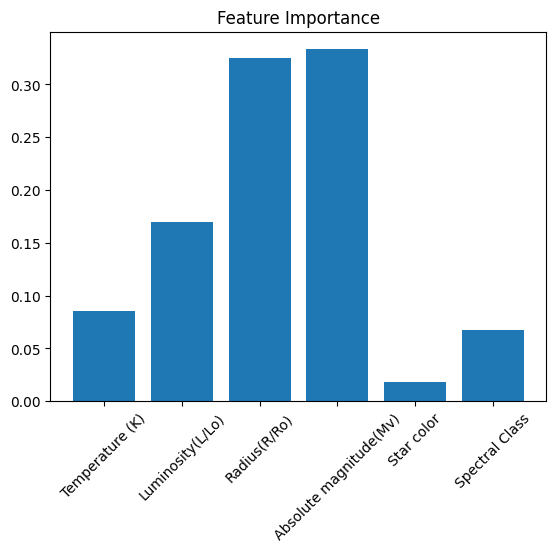

In [10]:
import matplotlib.pyplot as plt

importances = model.feature_importances_

plt.bar(X.columns, importances)
plt.xticks(rotation=45)
plt.title("Feature Importance")
plt.show()

In [11]:
plt.savefig("feature_importance.png")

<Figure size 640x480 with 0 Axes>

## 11. Results and Conclusion

The machine learning model successfully classifies stars based on their physical and spectral properties, achieving strong predictive performance on the test dataset.

Feature importance analysis indicates that absolute magnitude and stellar radius are the most influential parameters in determining star type, while derived attributes such as star color contribute minimally. This suggests that intrinsic brightness and structural scale are dominant factors in stellar classification.

The results align with established astrophysical understanding, demonstrating that machine learning models can effectively capture relationships between observable stellar properties and their underlying classifications.

This project illustrates how data-driven methods can be applied to astrophysical problems, providing both predictive capability and interpretability. Future work can extend this approach to larger astronomical datasets such as Gaia or TESS for more advanced analysis.